In [7]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
import math
import seaborn as sns
import os

# Set the style for seaborn
sns.set(style="whitegrid")
# Define the directory where the images are stored
image_dir = os.path.join(os.getcwd(), 'Figures')
print(f"Image directory: {image_dir}")
# Ensure the directory exists
if not os.path.exists(image_dir):
    os.makedirs(image_dir)

Image directory: c:\Users\User\OneDrive\Documentos\Teaching\PolEcon-Oxford2025\03 Simulations\Week3\Figures


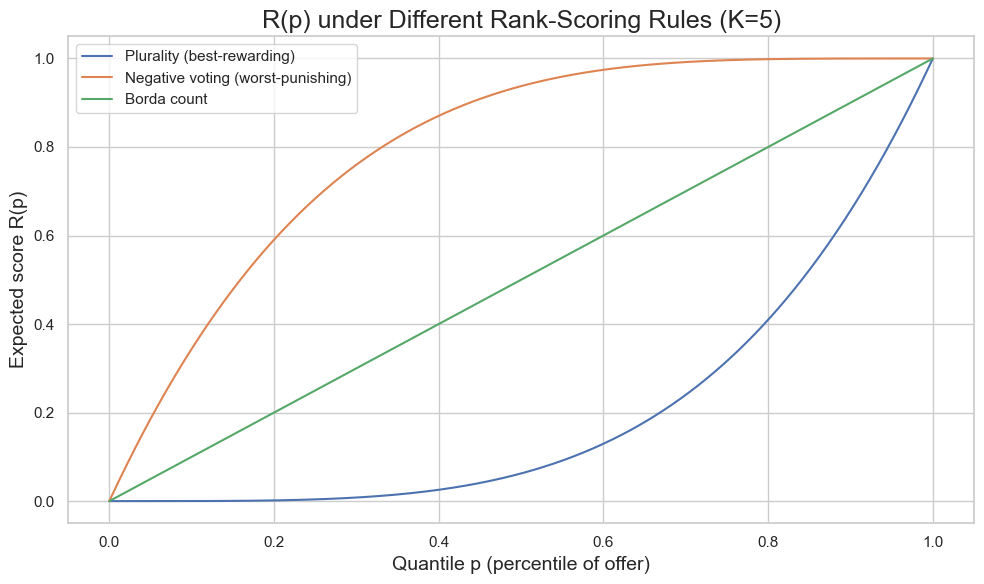

In [10]:
def compute_R_p_corrected(p_vals, s):
    """Compute R(p) given scoring vector s and a range of p values."""
    K = len(s)
    R_p = []
    for p in p_vals:
        total = 0
        for j in range(1, K+1):
            coeff = s[j-1]
            binom_coeff = comb(K-1, j-1)
            term = coeff * binom_coeff * (p**(K - j)) * ((1 - p)**(j - 1))
            total += term
        R_p.append(total)
    return np.array(R_p)

# Define p values
p_vals = np.linspace(0, 1, 500)

# Define scoring rules
scoring_rules = {
    "Plurality (best-rewarding)": [1] + [0]*4,         # K=5
    "Negative voting (worst-punishing)": [1]*4 + [0],  # K=5
    "Borda count": [(4-i)/4 for i in range(5)],         # K=5
}

# Compute R(p) for each rule
R_results = {label: compute_R_p_corrected(p_vals, s) for label, s in scoring_rules.items()}

# Plot
plt.figure(figsize=(10, 6))
for label, R in R_results.items():
    plt.plot(p_vals, R, label=label)

plt.title("R(p) under Different Rank-Scoring Rules (K=5)", fontsize=18)
plt.xlabel("Quantile p (percentile of offer)", fontsize=14)
plt.ylabel("Expected score R(p)", fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
# Save the plot
plt.savefig(os.path.join(image_dir, 'myerson1993_R_p_scoring_rules_K5.png'), dpi=300)
plt.show()